In [59]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [67]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import zipfile
import tempfile
import time
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Critical-difference visualization (aeon)
try:
    from aeon.visualisation import plot_critical_difference
except ImportError:
    print("aeon unavailable. Run `pip install aeon` in a terminal if needed.")

# ===================== Initial settings =====================
RESULTS_DIR = ROOT / "results"
KERAS_DIR = ROOT / "keras_models"
TFLITE_DIR = ROOT / "tflite_models"
WAKE_TFLITE_DIR = ROOT / "exports" / "wakevision" / "tflite_models"

MODEL_NAMES = ["MobileNetV3Small", "EfficientNetB0", "MCUNet_Official"]
DISPLAY_NAMES = {
    "MobileNetV3Small": "MobileNetV3-Small",
    "EfficientNetB0": "EfficientNet-B0",
    "MCUNet_Official": "MCUNet",
}

# Allows unifying model names from different files
MODEL_ALIASES = {
    "MCUNet": "MCUNet_Official",
    "MCUNet_Official": "MCUNet_Official",
    "MobileNetV3Small": "MobileNetV3Small",
    "EfficientNetB0": "EfficientNetB0",
}

SEVERITIES = [1, 2, 3, 4, 5]

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def err_from_acc(acc):
    return 1.0 - float(acc)


In [69]:
# =============================================================================
# 1. Load data: robustness (CE by corruption)
# =============================================================================

def get_corruption_errors(dataset_name, jsonl_path, baseline_acc_path):
    ce_results = _load_jsonl(jsonl_path)
    baseline_acc = _load_json(baseline_acc_path)
    corruptions_list = list(baseline_acc.keys())

    results_by_model = {name: {} for name in MODEL_NAMES}
    for r in ce_results:
        model_name = MODEL_ALIASES.get(r["model"], r["model"])
        if model_name in MODEL_NAMES:
            results_by_model[model_name][r["corruption"]] = r

    data = []
    for model in MODEL_NAMES:
        for c in corruptions_list:
            if c not in results_by_model[model]:
                continue
            r = results_by_model[model][c]
            base = baseline_acc[c]

            # CE = Σ_s err_model(s) / Σ_s err_baseline(s)
            num_err = sum(err_from_acc(r[f"acc_s{s}"]) for s in SEVERITIES)
            den_err = sum(err_from_acc(base[f"acc_s{s}"]) for s in SEVERITIES)
            ce = (num_err / den_err) * 100 if den_err > 0 else float("nan")

            data.append({
                "Dataset": dataset_name,
                "Model": model,
                "Corruption": c,
                "CE": ce
            })
    return data

# Extracting for CIFAR-10-C, CIFAR-100-C, and Wake Vision
c10_data = get_corruption_errors(
    "CIFAR10",
    RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl",
    RESULTS_DIR / "cifar10c_baseline-MCUNet_baseline_acc.json"
)
c100_data = get_corruption_errors(
    "CIFAR100",
    RESULTS_DIR / "cifar100c_baseline-MCUNet_ce_results.jsonl",
    RESULTS_DIR / "cifar100c_baseline-MCUNet_baseline_acc.json"
)
wake_data = get_corruption_errors(
    "WakeVision",
    RESULTS_DIR / "wakevision_baseline-MCUNet_ce_results.jsonl",
    RESULTS_DIR / "wakevision_baseline-MCUNet_baseline_acc.json"
)

df_ce = pd.DataFrame(c10_data + c100_data + wake_data)
print("Robustness Data Sample (CE):")
display(df_ce.head())

Robustness Data Sample (CE):


,Dataset,Model,Corruption,CE
0,CIFAR10,MobileNetV3Small,brightness,32.918345
1,CIFAR10,MobileNetV3Small,contrast,74.596397
2,CIFAR10,MobileNetV3Small,defocus_blur,48.789547
3,CIFAR10,MobileNetV3Small,elastic_transform,57.404988
4,CIFAR10,MobileNetV3Small,fog,77.559234


In [70]:
# =============================================================================
# 2. Load/Processar Dados: LATÊNCIA
# =============================================================================

TFLITE_FILES = {
    "CIFAR10": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR10.tflite",
        "EfficientNetB0":   "EfficientNetB0_CIFAR10.tflite",
        "MCUNet_Official":  "MCUNet_Official_CIFAR10.tflite",
    },
    "CIFAR100": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR100.tflite",
        "EfficientNetB0":   "EfficientNetB0_CIFAR100.tflite",
        "MCUNet_Official":  "MCUNet_Official_CIFAR100.tflite",
    },
    "WakeVision": {
        "MobileNetV3Small": "MobileNetV3Small_wake_vision.tflite",
        "EfficientNetB0":   "EfficientNetB0_wake_vision.tflite",
        "MCUNet_Official":  "MCUNet_wake_vision.tflite",
    },
}

TFLITE_DIRS = {
    "CIFAR10": TFLITE_DIR,
    "CIFAR100": TFLITE_DIR,
    "WakeVision": WAKE_TFLITE_DIR if WAKE_TFLITE_DIR.exists() else TFLITE_DIR,
}

def get_latencies(dataset_name, num_warmup=10, num_runs=100):
    data = []
    dataset_tflite_dir = TFLITE_DIRS[dataset_name]
    for model in MODEL_NAMES:
        tflite_path = dataset_tflite_dir / TFLITE_FILES[dataset_name][model]
        if not tflite_path.exists():
            continue
            
        interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        inp = interpreter.get_input_details()[0]
        dummy = np.random.uniform(0, 255, size=inp['shape']).astype(np.float32)

        # Warmup
        for _ in range(num_warmup):
            interpreter.set_tensor(inp['index'], dummy)
            interpreter.invoke()

        # Measurements
        for i in range(num_runs):
            t0 = time.perf_counter()
            interpreter.set_tensor(inp['index'], dummy)
            interpreter.invoke()
            t1 = time.perf_counter()
            
            data.append({
                "Dataset": dataset_name,
                "Model": model,
                "Run": i,
                "Latency_ms": (t1 - t0) * 1000
            })
    return data

lat_c10 = get_latencies("CIFAR10")
lat_c100 = get_latencies("CIFAR100")
lat_wake = get_latencies("WakeVision")

df_latency = pd.DataFrame(lat_c10 + lat_c100 + lat_wake)
print("Latency data sample:")
display(df_latency.head())

c:\Users\saulo\PIBIC\Lightweight Analyses\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Latency data sample:


,Dataset,Model,Run,Latency_ms
0,CIFAR10,MobileNetV3Small,0,4.2236
1,CIFAR10,MobileNetV3Small,1,4.2884
2,CIFAR10,MobileNetV3Small,2,4.6240
3,CIFAR10,MobileNetV3Small,3,5.0067
4,CIFAR10,MobileNetV3Small,4,6.2246


In [71]:
def rank_metric(df, index_cols, columns, values, ascending=True):
    """
    Ranks the values for each block (index_cols) across treatments (columns).
    """
    pivot = df.pivot_table(index=index_cols, columns=columns, values=values)
    ranked = pivot.rank(axis=1, ascending=ascending)
    return pivot, ranked

def friedman_test(df_ranked, metric_name):
    # Extract the data as a list of arrays (one for each treatment)
    data = [df_ranked[column].dropna().values for column in df_ranked.columns]
    
    # Perform the Friedman test
    friedman_result = stats.friedmanchisquare(*data)

    print(f"Friedman test for {metric_name}")
    print(f"Statistic: {friedman_result.statistic:.4f}")
    print(f"p-value: {friedman_result.pvalue:.4e}")
    return friedman_result

def generate_critical_difference(df_ranked, output_pdf, plot_title, lower_better=True, test='nemenyi'):
    scores = df_ranked.values
    classifiers = df_ranked.columns.tolist()
    
    # Check if we have NaN values. Nemenyi test requires complete blocks usually.
    if np.isnan(scores).any():
        print("Warning: NaNs in ranks. Dropping incomplete rows for the CD plot.")
        df_ranked = df_ranked.dropna()
        scores = df_ranked.values
    
    # Display names mapped to classifiers
    mapped_classifiers = [DISPLAY_NAMES.get(c, c) for c in classifiers]
    
    # Create figure with more height for better label spacing
    plt.figure(figsize=(12, 6))
    
    plot_critical_difference(
        scores,
        mapped_classifiers,
        lower_better=lower_better,
        test=test, 
        correction='holm', 
    )

    ax = plt.gca()
    ax.set_title(plot_title, pad=20)

    # Margins and label spaces - add more top margin for ranking numbers
    plt.subplots_adjust(bottom=0.35, top=0.88, left=0.12, right=0.95)
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

--- FRIEDMAN TEST FOR ROBUSTNESS (CE) ---


Model                      EfficientNetB0  MCUNet_Official  MobileNetV3Small
Dataset Corruption                                                          
CIFAR10 brightness                    1.0              3.0               2.0
        contrast                      1.0              3.0               2.0
        defocus_blur                  1.0              3.0               2.0
        elastic_transform             1.0              3.0               2.0
        fog                           1.0              3.0               2.0

Friedman test for Corruption Error (CE)
Statistic: 104.4561
p-value: 2.0780e-23

Generating critical-difference diagram for robustness...


<Figure size 1200x600 with 0 Axes>

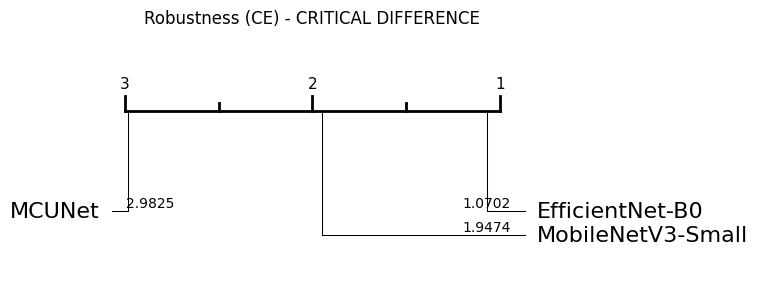

In [72]:
# =============================================================================
# 4. Tests for robustness (corruption error)
# =============================================================================
# Here treatments are the models, and blocks are (dataset, corruption) pairs.
print("--- FRIEDMAN TEST FOR ROBUSTNESS (CE) ---")
# lower is better (ascending = True)
df_ce_pivot, df_ce_ranked = rank_metric(
    df_ce, 
    index_cols=['Dataset', 'Corruption'], 
    columns='Model', 
    values='CE', 
    ascending=True
)

display(df_ce_ranked.head())
friedman_test(df_ce_ranked, "Corruption Error (CE)")

print("\nGenerating critical-difference diagram for robustness...")
generate_critical_difference(
    df_ce_ranked, 
    ROOT / "figures" / "cd_robustness_ce.pdf", 
    'Robustness (CE) - CRITICAL DIFFERENCE', 
    lower_better=True, 
    test='nemenyi'
)

In [65]:
# =============================================================================
# 5. Tests for latency
# =============================================================================
# Here treatments are models, and blocks are run groups per dataset.
# With 100 runs per dataset and 3 datasets (CIFAR10, CIFAR100 and WakeVision), we have up to 300 blocks.
print("--- FRIEDMAN TEST FOR LATENCY ---")
# lower is better (ascending = True)
df_lat_pivot, df_lat_ranked = rank_metric(
    df_latency, 
    index_cols=['Dataset', 'Run'], 
    columns='Model', 
    values='Latency_ms', 
    ascending=True
)

display(df_lat_ranked.head())
friedman_test(df_lat_ranked, "Latency (ms)")

print("\nGenerating critical-difference diagram for latency...")
generate_critical_difference(
    df_lat_ranked, 
    ROOT / "figures" / "cd_latency.pdf", 
    'Latency - CRITICAL DIFFERENCE', 
    lower_better=True, 
    test='nemenyi'
)

--- FRIEDMAN TEST FOR LATENCY ---


Model        EfficientNetB0  MCUNet_Official  MobileNetV3Small
Dataset Run                                                   
CIFAR10 0               2.0              3.0               1.0
        1               2.0              3.0               1.0
        2               3.0              2.0               1.0
        3               2.0              3.0               1.0
        4               2.0              3.0               1.0

ValueError: Array shapes are incompatible for broadcasting.

In [ ]:
# =============================================================================
# 6. Testes para Tamanho (Size)
# =============================================================================
# Model size is deterministic and has no variance within the same pipeline.
# Here we use the CIFAR-10, CIFAR-100, and Wake Vision datasets for a descriptive comparison.

def compute_sizes(dataset_name):
    data = []
    dataset_tflite_dir = TFLITE_DIRS[dataset_name]
    
    def get_size(path):
        return Path(path).stat().st_size / (1024 * 1024) if Path(path).exists() else float('nan')
        
    for model in MODEL_NAMES:
        tflite_path = dataset_tflite_dir / TFLITE_FILES[dataset_name][model]
        ts = get_size(tflite_path)
        data.append({
            "Dataset": dataset_name,
            "Model": model,
            "TFLite_Size_MB": ts
        })
    return data

size_data = compute_sizes("CIFAR10") + compute_sizes("CIFAR100") + compute_sizes("WakeVision")
df_size = pd.DataFrame(size_data)

print("--- RANKING FOR MODEL SIZE (TFLite MB) ---")
df_size_pivot, df_size_ranked = rank_metric(
    df_size, 
    index_cols=['Dataset'], 
    columns='Model', 
    values='TFLite_Size_MB', 
    ascending=True # Smaller size is better
)

print("\nSize (MB):")
display(df_size_pivot)
print("\nRanks (1 = Smallest/Best):")
display(df_size_ranked)

--- RANKING FOR MODEL SIZE (TFLite MB) ---

Size (MB):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR10,15.346325,5.386055,3.579590
CIFAR100,15.786594,5.496407,3.777969
WakeVision,15.334347,5.398678,3.591373



Ranks (1 = Smallest/Best):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR10,3.0,2.0,1.0
CIFAR100,3.0,2.0,1.0
WakeVision,3.0,2.0,1.0


Combined device metrics sample:


,Device,Dataset,Model,P90_Latency_ms,Throughput_FPS,Accuracy
0,Mobile,CIFAR10,EfficientNetB0,39.849985,21.447287,0.9400
1,Mobile,CIFAR10,MCUNet,16.865550,38.543150,0.7350
2,Mobile,CIFAR10,MobileNetV3Small,4.529466,69.951399,0.8925
3,Mobile,CIFAR100,EfficientNetB0,39.603442,20.926452,0.8200
4,Mobile,CIFAR100,MCUNet,16.905766,38.687607,0.5325


--- RANKING FOR P90 LATENCY (MOBILE + RASPBERRY) ---


Model                 EfficientNetB0      MCUNet  MobileNetV3Small
Device    Dataset                                                 
Mobile    CIFAR10          26.358782   11.424830          3.180106
          CIFAR100         28.322281   12.419879          3.314204
          WakeVision       56.633625   25.291880          6.462622
Raspberry CIFAR10         350.342199  182.696565         25.628778
          CIFAR100        350.849368  182.959297         25.746796
          WakeVision      663.061258  462.203251         51.024721


Ranks (1 = Smallest/Best):


Model                 EfficientNetB0  MCUNet  MobileNetV3Small
Device    Dataset                                             
Mobile    CIFAR10                3.0     2.0               1.0
          CIFAR100               3.0     2.0               1.0
          WakeVision             3.0     2.0               1.0
Raspberry CIFAR10                3.0     2.0               1.0
          CIFAR100               3.0     2.0               1.0
          WakeVision             3.0     2.0               1.0

Friedman test for P90 Latency (Mobile + Raspberry)
Statistic: 12.0000
p-value: 2.4788e-03

Generating critical-difference diagram for latency P90 (Mobile + Raspberry)...


<Figure size 1200x600 with 0 Axes>

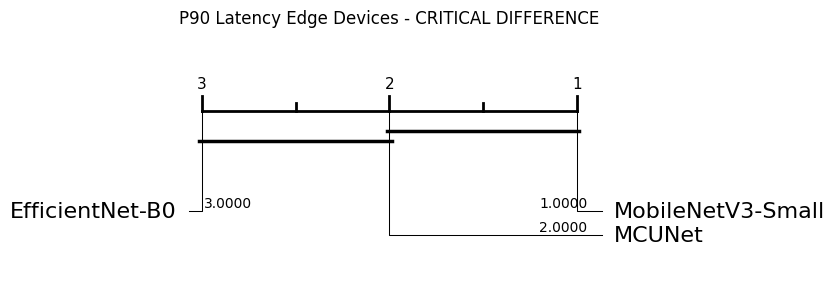


--- RANKING FOR THROUGHPUT (MOBILE + RASPBERRY) ---


Model                 EfficientNetB0     MCUNet  MobileNetV3Small
Device    Dataset                                                
Mobile    CIFAR10          40.695435  70.455211        114.288882
          CIFAR100         34.002437  62.061640        111.728136
          WakeVision       15.766051  25.538117         42.212574
Raspberry CIFAR10           2.832702   5.390953         34.057784
          CIFAR100          2.827997   5.384876         33.895259
          WakeVision        1.385579   1.912348          8.687325


Ranks (1 = Largest/Best):


Model                 EfficientNetB0  MCUNet  MobileNetV3Small
Device    Dataset                                             
Mobile    CIFAR10                3.0     2.0               1.0
          CIFAR100               3.0     2.0               1.0
          WakeVision             3.0     2.0               1.0
Raspberry CIFAR10                3.0     2.0               1.0
          CIFAR100               3.0     2.0               1.0
          WakeVision             3.0     2.0               1.0


Generating critical-difference diagram for throughput (Mobile + Raspberry)...


<Figure size 1200x600 with 0 Axes>

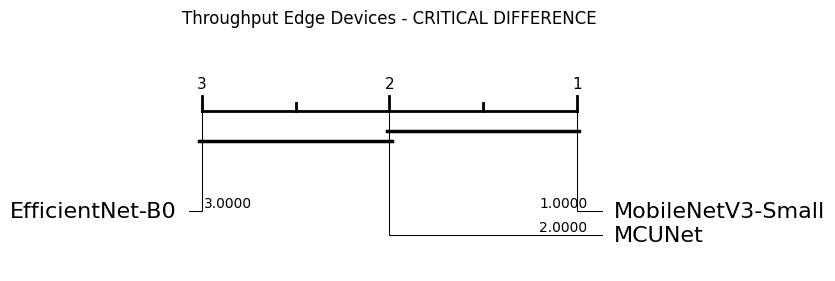

In [66]:
# =============================================================================
# 7. Testes Estatísticos para as Métricas do Celular e Raspberry
# =============================================================================
# Abaixo unificamos os dados reais do celular e do Raspberry para gerar os testes estatísticos.


def normalize_model_name(model_name):
    base_model = str(model_name)
    normalized = base_model.lower()
    if "efficientnet" in normalized:
        return "EfficientNetB0"
    if "mcunet" in normalized or normalized == "lcnn":
        return "MCUNet"
    if "mobilenet" in normalized:
        return "MobileNetV3Small"
    return base_model


def normalize_dataset_name(dataset_name):
    key = str(dataset_name).lower()
    if key in {"cifar10", "cifar-10"}:
        return "CIFAR10"
    if key in {"cifar100", "cifar-100"}:
        return "CIFAR100"
    if key == "wakevision":
        return "WakeVision"
    return str(dataset_name)


def load_mobile_metrics(json_files, device_name):
    rows = []
    for file_path in json_files:
        if not os.path.exists(file_path):
            continue
        with open(file_path, "r", encoding="utf-8") as file_handle:
            content = json.load(file_handle)
        for model in content.get("models", []):
            rows.append({
                "Device": device_name,
                "Dataset": model["datasetName"],
                "Model": normalize_model_name(model["modelName"]),
                "P90_Latency_ms": model["p90LatencyMs"],
                "Throughput_FPS": model["throughputImagesPerSecond"],
                "Accuracy": model["accuracy"],
            })
    return rows


def load_raspberry_metrics(json_path, device_name):
    rows = []
    if not os.path.exists(json_path):
        return rows
    with open(json_path, "r", encoding="utf-8") as file_handle:
        content = json.load(file_handle)
    for dataset_name, dataset_payload in content.get("datasets", {}).items():
        for model_name, model_payload in dataset_payload.get("models", {}).items():
            rows.append({
                "Device": device_name,
                "Dataset": normalize_dataset_name(dataset_name),
                "Model": normalize_model_name(model_payload["model"]),
                "P90_Latency_ms": model_payload["latency_ms"]["p90"],
                "Throughput_FPS": model_payload["throughput_img_s"],
                "Accuracy": model_payload["accuracy"],
            })
    return rows


json_files_mobile = [
    RESULTS_DIR / "a14_metrics_cifar10_cpu_400imgs_1775245845979.json",
    RESULTS_DIR / "a14_metrics_cifar100_cpu_400imgs_1775245894612.json",
    RESULTS_DIR / "a14_metrics_wakevision_cpu_400imgs_1775245982177.json",
    RESULTS_DIR / "s24p_metrics_cifar10_cpu_400imgs_1775267671116.json",
    RESULTS_DIR / "s24p_metrics_cifar100_cpu_400imgs_1775267691899.json",
    RESULTS_DIR / "s24p_metrics_wakevision_cpu_400imgs_1775267738764.json",
]

json_raspberry = RESULTS_DIR / "raspberry" / "results" / "results_merged.json"

combined_rows = []
combined_rows.extend(load_mobile_metrics(json_files_mobile, "Mobile"))
combined_rows.extend(load_raspberry_metrics(json_raspberry, "Raspberry"))

df_device_metrics = pd.DataFrame(combined_rows)
df_device_metrics["Dataset"] = df_device_metrics["Dataset"].replace({
    "cifar10": "CIFAR10",
    "cifar100": "CIFAR100",
    "wakevision": "WakeVision",
    "CIFAR-10": "CIFAR10",
    "CIFAR-100": "CIFAR100",
})

print("Combined device metrics sample:")
display(df_device_metrics.head())


# ---- 7.1 Teste para Latency P90 (Mobile + Raspberry) ----
print("--- RANKING FOR P90 LATENCY (MOBILE + RASPBERRY) ---")
# Menor latência é melhor (ascending=True)
df_dev_lat_pivot, df_dev_lat_ranked = rank_metric(
    df_device_metrics,
    index_cols=["Device", "Dataset"],
    columns="Model",
    values="P90_Latency_ms",
    ascending=True
)

display(df_dev_lat_pivot)
print("\nRanks (1 = Smallest/Best):")
display(df_dev_lat_ranked)

try:
    friedman_test(df_dev_lat_ranked, "P90 Latency (Mobile + Raspberry)")
except Exception as e:
    print(f"Aviso no teste de Friedman: {e}")

print("\nGenerating critical-difference diagram for latency P90 (Mobile + Raspberry)...")
generate_critical_difference(
    df_dev_lat_ranked,
    ROOT / "figures" / "cd_device_p90_latency.pdf",
    "P90 Latency Edge Devices - CRITICAL DIFFERENCE",
    lower_better=True,
    test="nemenyi"
 )


# ---- 7.2 Teste para Throughput (Mobile + Raspberry) ----
print("\n--- RANKING FOR THROUGHPUT (MOBILE + RASPBERRY) ---")
# Maior throughput é melhor (ascending=False)
df_dev_thr_pivot, df_dev_thr_ranked = rank_metric(
    df_device_metrics,
    index_cols=["Device", "Dataset"],
    columns="Model",
    values="Throughput_FPS",
    ascending=False
)

display(df_dev_thr_pivot)
print("\nRanks (1 = Largest/Best):")
display(df_dev_thr_ranked)

print("\nGenerating critical-difference diagram for throughput (Mobile + Raspberry)...")
generate_critical_difference(
    df_dev_thr_ranked,
    ROOT / "figures" / "cd_device_throughput.pdf",
    "Throughput Edge Devices - CRITICAL DIFFERENCE",
    lower_better=True,
    test="nemenyi"
 )
